This notebook contains comparisons, convergence tests and benchmark runs between the new simulator in rust and the original CasADi one.
It also demonstrates how to use the simulators.

In [2]:
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt

import manywells.simulator as sim
import manywells_rs as sim_rs

from scripts.compare_simulators import run_convergence, plot_convergence, run_benchmark, compare_operating_point
from scripts.plot_simulator import plot_residual, plot_solution
from scripts.load_well_from_dataset import load_well_config

%load_ext autoreload
%autoreload 2

I downloaded the dataset locally to ease the development process. [Download the manywells datasets](https://huggingface.co/datasets/solution-seeker-as/manywells) and store them under `data/`.

In [4]:
dataset_name_sol = "manywells-sol"

df_sol = pd.read_csv(f"data/{dataset_name_sol}/{dataset_name_sol}-1.zip", compression="zip")
config_sol = pd.read_csv(f"data/{dataset_name_sol}/{dataset_name_sol}-1_config.zip", compression="zip")

dataset_name_nsol = "manywells-nsol"

df_nsol = pd.read_csv(f"data/{dataset_name_nsol}/{dataset_name_nsol}-1.zip", compression="zip")
config_nsol = pd.read_csv(f"data/{dataset_name_nsol}/{dataset_name_nsol}-1_config.zip", compression="zip")

dataset_name_nscl = "manywells-nscl"

df_nscl = pd.read_csv(f"data/{dataset_name_nscl}/{dataset_name_nscl}-1.zip", compression="zip")
config_nscl = pd.read_csv(f"data/{dataset_name_nscl}/{dataset_name_nscl}-1_config.zip", compression="zip")

# Recreate histograms from figure 8 in paper, and compare against dataset generated by new simulator


In [3]:
def compare_distributions(df_old, df_new, filename=None):
    import matplotlib.pyplot as plt

    plt.clf()
    fig, axs = plt.subplots(3, 3, figsize=(16, 8))
    fig.delaxes(axs[2, 2])
    
    (df_old['CHK']*100).hist(alpha=0.5, density=True, bins=25, ax=axs[0,0], label="old")
    (df_new['CHK']*100).hist(alpha=0.5, density=True, bins=25, ax=axs[0,0], label="rs")
    axs[0, 0].set(xlabel="CHK (%)", ylabel="density")
    
    df_old['QGL'].hist(alpha=0.5, density=True, bins=25, ax = axs[0, 1], label="old")
    df_new['QGL'].hist(alpha=0.5, density=True, bins=25, ax = axs[0, 1], label="rs")
    axs[0, 1].set(xlabel="QGL (Sm3/h)", ylabel="density")
    
    df_old['FGAS'].hist(alpha=0.5, density=True, bins=25, ax = axs[0, 2], label="old")
    df_new['FGAS'].hist(alpha=0.5, density=True, bins=25, ax = axs[0, 2], label="rs")
    axs[0, 2].set(xlabel="FGAS (-)", ylabel="density")
    
    df_old['FOIL'].hist(alpha=0.5, density=True, bins=25, ax = axs[1, 0], label="old")
    df_new['FOIL'].hist(alpha=0.5, density=True, bins=25, ax = axs[1, 0], label="rs")
    axs[1, 0].set(xlabel="FOIL (-)", ylabel="density")
    
    df_old['PWH'].hist(alpha=0.5, density=True, bins=25, ax = axs[1,1], label="old")
    df_new['PWH'].hist(alpha=0.5, density=True, bins=25, ax = axs[1,1], label="rs")
    axs[1, 1].set(xlabel = "PWH (bar)", ylabel="density")
    
    df_old['PDC'].hist(alpha=0.5, density=True, bins=25, ax = axs[1,2], label="old")
    df_new['PDC'].hist(alpha=0.5, density=True, bins=25, ax = axs[1,2], label="rs")
    axs[1, 2].set(xlabel = "PDC  (bar)", ylabel="density")
    
    df_old['TWH'].hist(alpha=0.5, density=True, bins=25, ax = axs[2, 0], label="old")
    df_new['TWH'].hist(alpha=0.5, density=True, bins=25, ax = axs[2, 0], label="rs")
    axs[2, 0].set(xlabel = "TWH (K)", ylabel="density")
    
    df_old['QTOT'].hist(alpha=0.5, density=True, bins=25, ax = axs[2, 1], label="old")
    df_new['QTOT'].hist(alpha=0.5, density=True, bins=25, ax = axs[2, 1], label="rs")
    axs[2, 1].set(xlabel = "QTOT (Sm3/h)", ylabel="density")
    
    for i in range(3):
        for j in range(3):
            if (i, j) != (2, 2):
                axs[i, j].legend(loc="lower center", bbox_to_anchor=(0.5, 1.02), ncol=2)
    
    fig.tight_layout()
    if filename:
        plt.savefig(f"{filename}.svg")
    
    plt.show()


First, this is generated with the `scripts/data_generation/open_loop_stationary/generate_well_data_rust_simulator.py` script.

In [4]:
dataset_name_sol_rs = "manywells-sol_rs"
df_sol_rs = pd.read_csv(f"data/{dataset_name_sol_rs}/{dataset_name_sol_rs}-1.csv")
config_sol_rs = pd.read_csv(f"data/{dataset_name_sol_rs}/{dataset_name_sol_rs}-1_config.csv")

<Figure size 640x480 with 0 Axes>

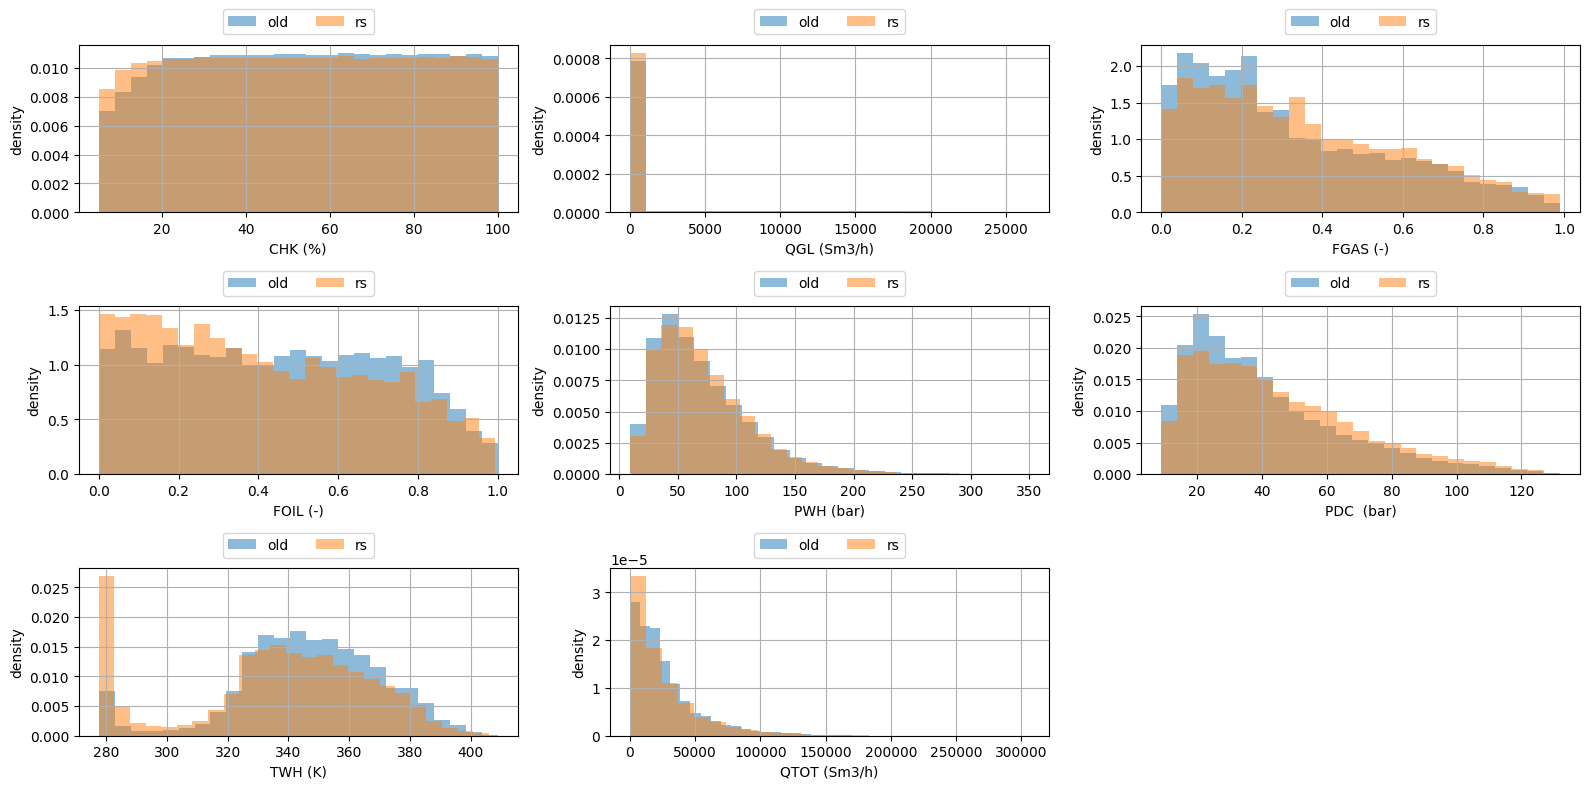

In [5]:
# overall comparison (all solutions that were found, including 2 solutions on one well config if solver found this)
compare_distributions(df_sol, df_sol_rs)

In [6]:
df_sol_rs_lowest = df_sol_rs[df_sol_rs['solution_number'] == 0] # lower pbh

idx = df_sol_rs.groupby(['ID', 'sample_id'])['solution_number'].idxmax()
df_sol_rs_highest = df_sol_rs.loc[idx] # max solution number. this gives only the highest pbh solution found (and includes those were only 1 sol were found)


# groups where more than one solution exists
grp = df_sol_rs.groupby(['ID', 'sample_id'])['solution_number']
counts = grp.transform('size')

df_multi = df_sol_rs[counts > 1]

idx_low = df_multi.groupby(['ID', 'sample_id'])['solution_number'].idxmin()
df_sol_rs_lowest_if_2 = df_multi.loc[idx_low]  # lowest pbh, only when >=2 solutions


df_sol_rs_highest_if_2 = df_sol_rs[df_sol_rs['solution_number'] == 1] # higher pbh (but might be problematic if only 1 sol were found)


---------------- sol -------------------
lowest: if 1 sol, then include it. if 2 sol, take solution_number 0


<Figure size 640x480 with 0 Axes>

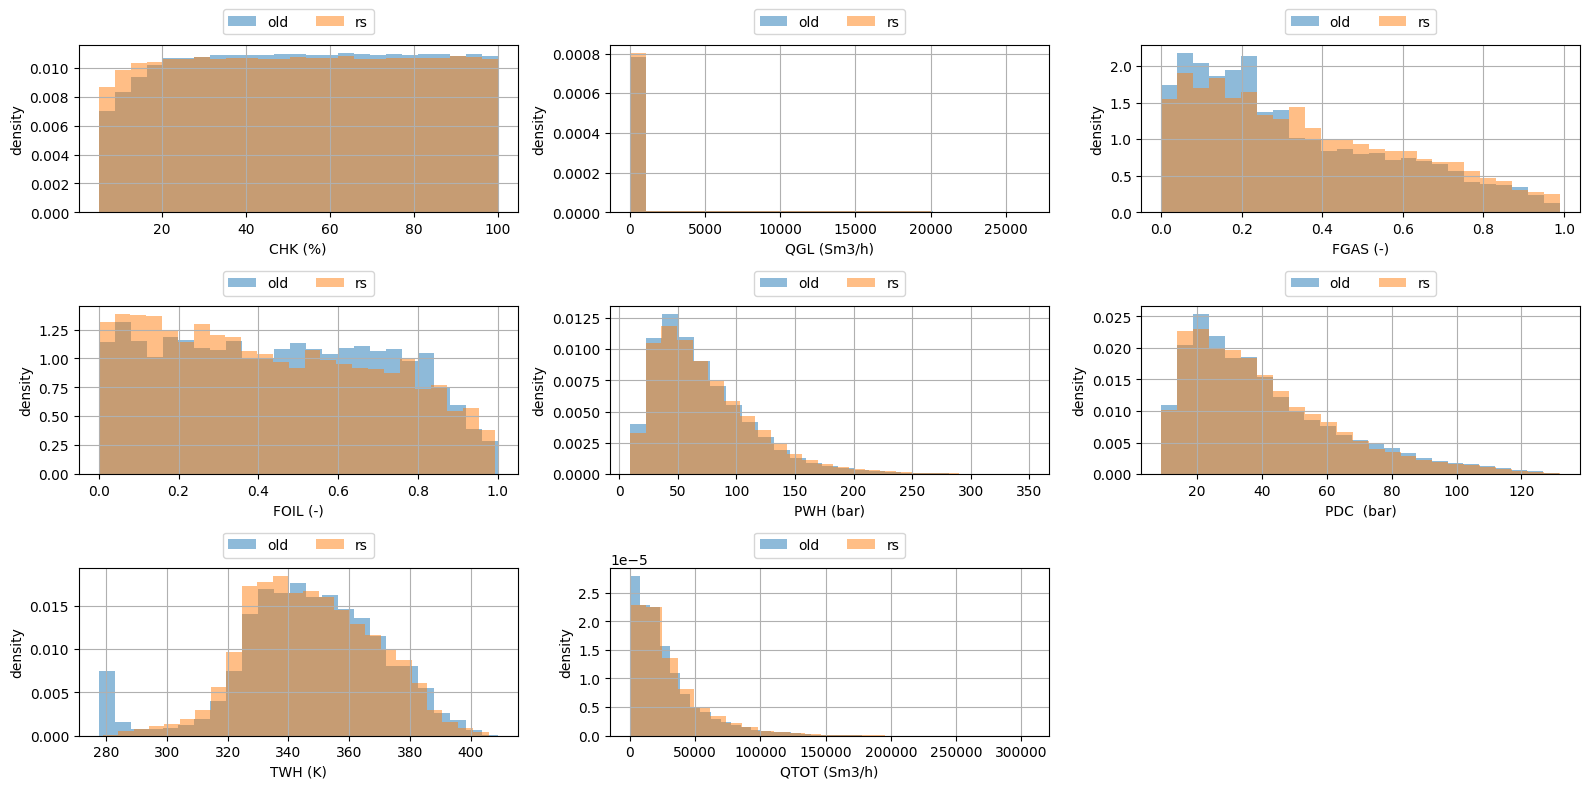

highest: if 1 sol, then include it. if 2 sol, take solution_number 1


<Figure size 640x480 with 0 Axes>

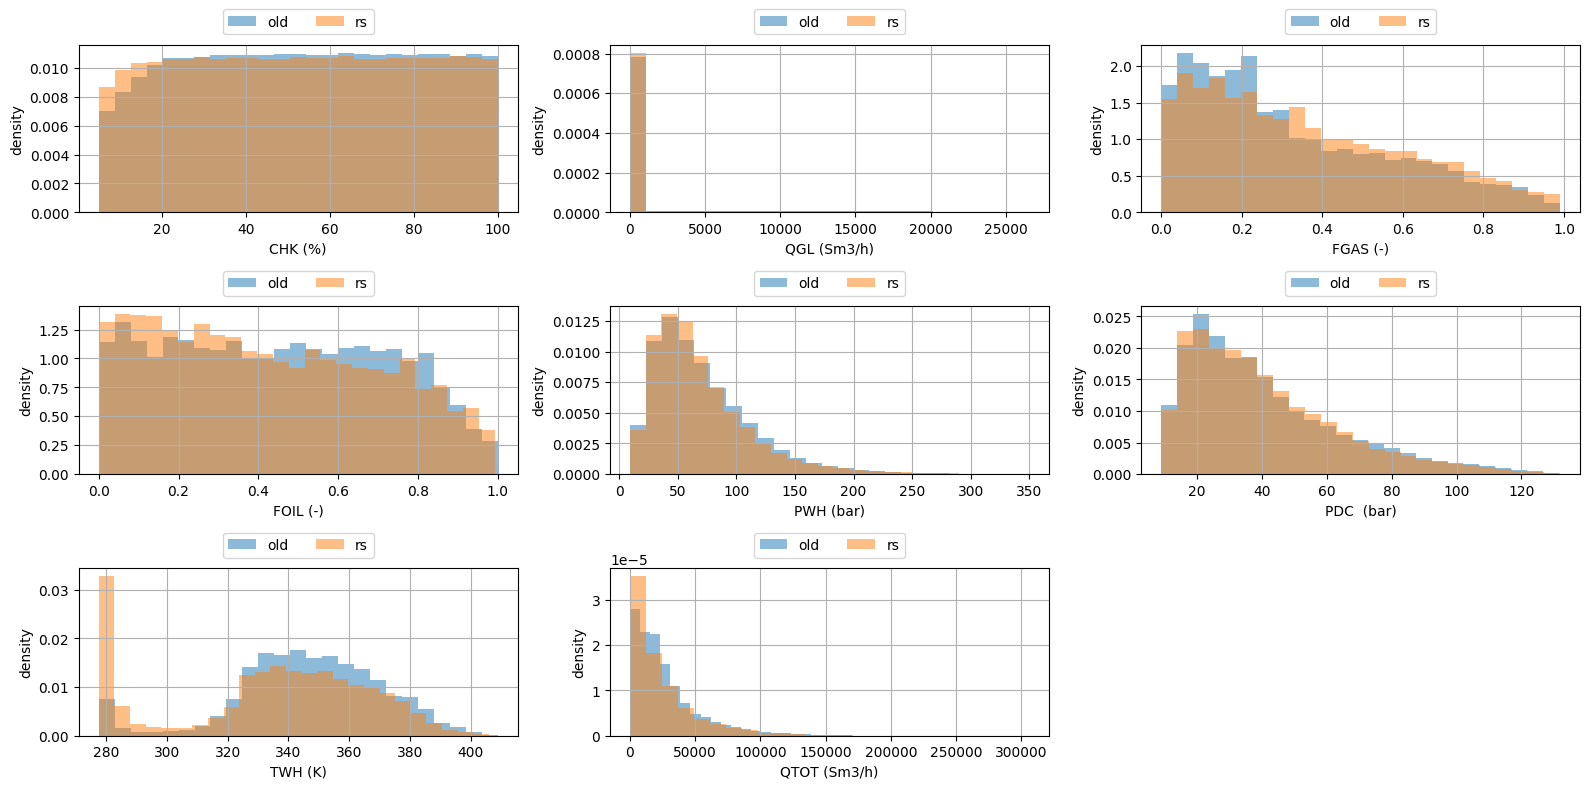

The lowest pbh solutions found, but excludes all cases were only one solution was found


<Figure size 640x480 with 0 Axes>

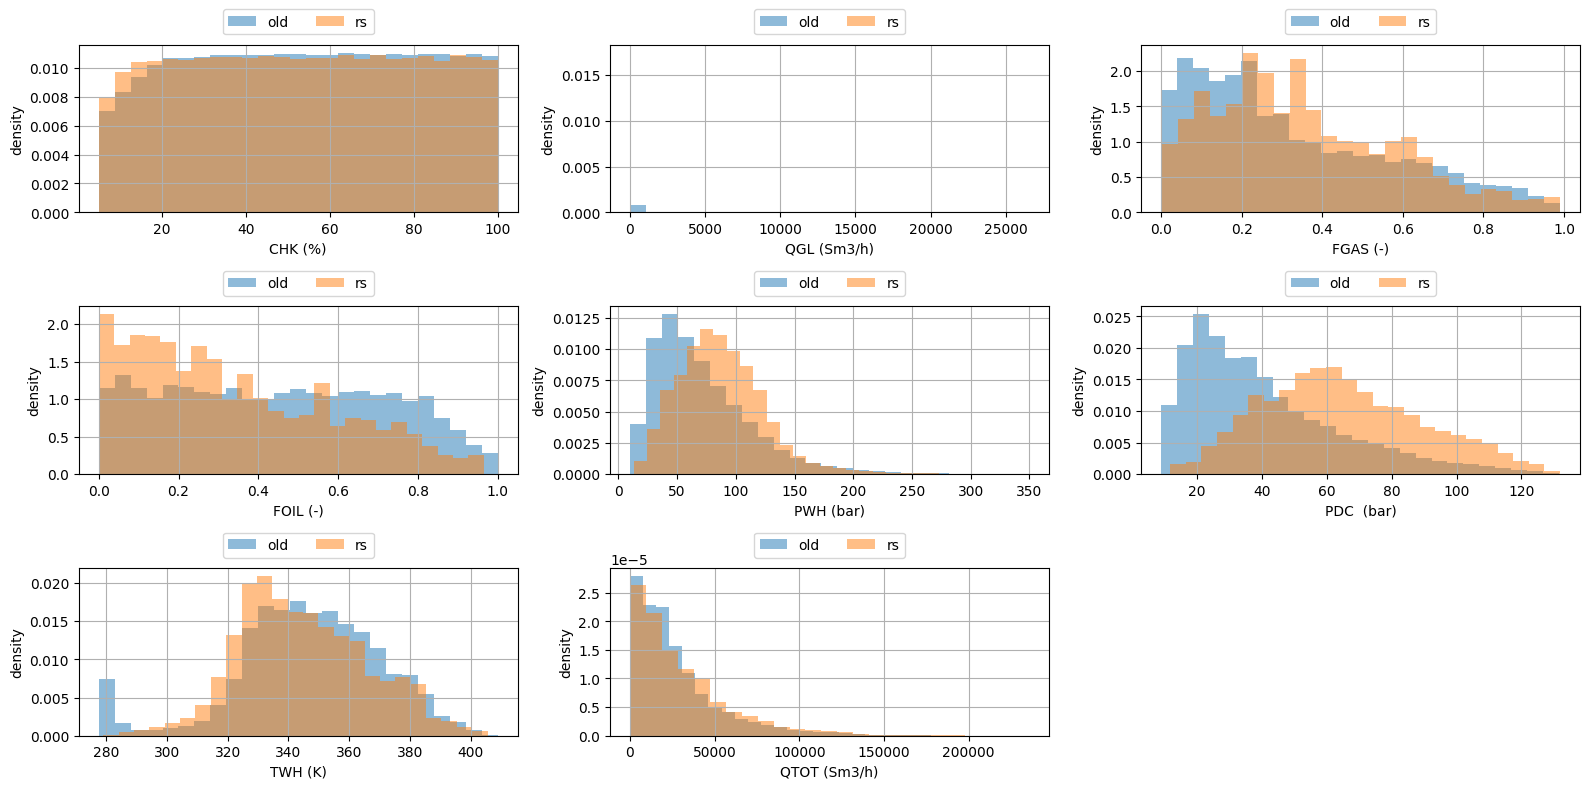

The highest pbh solutions found, but excludes all cases were only one solution was found


<Figure size 640x480 with 0 Axes>

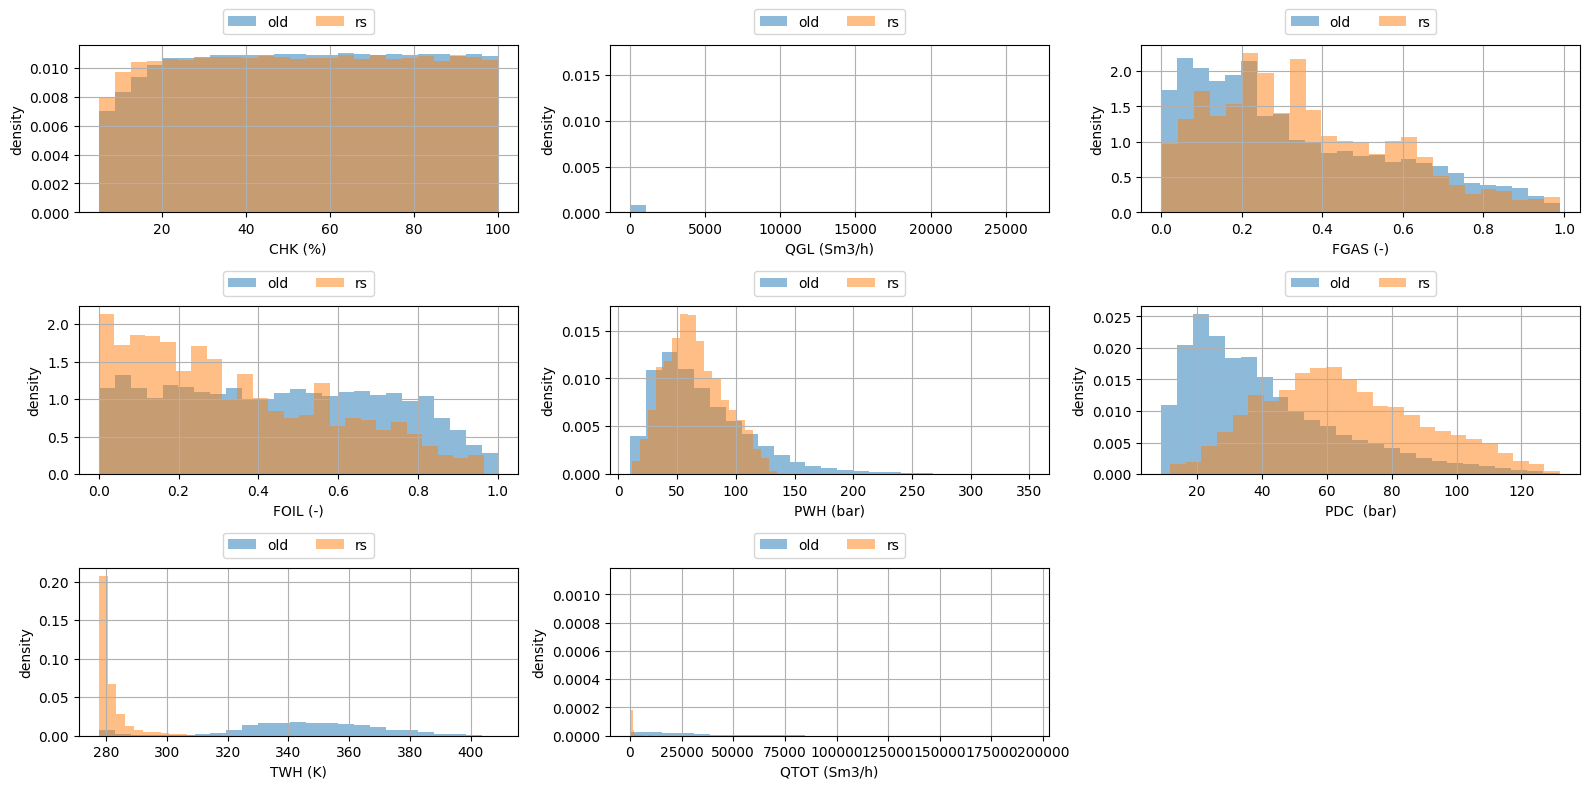

In [8]:
print("---------------- sol -------------------")
print("lowest: if 1 sol, then include it. if 2 sol, take solution_number 0")
compare_distributions(df_sol, df_sol_rs_lowest, filename="manywells_sol_compare_distributions_lowest_PBH")
print("highest: if 1 sol, then include it. if 2 sol, take solution_number 1")
compare_distributions(df_sol, df_sol_rs_highest, filename="manywells_sol_compare_distributions_highest_PBH")
print("The lowest pbh solutions found, but excludes all cases were only one solution was found")
compare_distributions(df_sol, df_sol_rs_lowest_if_2, filename="manywells_sol_compare_distributions_lowest_PBH_if_2_sols")
print("The highest pbh solutions found, but excludes all cases were only one solution was found")
compare_distributions(df_sol, df_sol_rs_highest_if_2, filename="manywells_sol_compare_distributions_highest_PBH_if_2_sols")


Then, I generated with the `scripts/data_generation/open_loop_nonstationary/generate_open_loop_nonstationary_well_data_rust_simulator.py` script.

In [9]:
dataset_name_nsol_rs = "manywells-nsol_rs"
df_nsol_rs = pd.read_csv(f"data/{dataset_name_nsol_rs}/{dataset_name_nsol_rs}-1.csv")
config_nsol_rs = pd.read_csv(f"data/{dataset_name_nsol_rs}/{dataset_name_nsol_rs}-1_config.csv")

In [10]:
df_nsol_rs_lowest = df_nsol_rs[df_nsol_rs['solution_number'] == 0] # lower pbh
idx = df_nsol_rs.groupby(['ID', 'sample_id'])['solution_number'].idxmax()
df_nsol_rs_highest = df_nsol_rs.loc[idx] # max solution number. this gives only the highest pbh solution found (and includes those were only 1 sol were found)


# groups where more than one solution exists
grp = df_nsol_rs.groupby(['ID', 'sample_id'])['solution_number']
counts = grp.transform('size')

df_multi = df_nsol_rs[counts > 1]

idx_low = df_multi.groupby(['ID', 'sample_id'])['solution_number'].idxmin()
df_nsol_rs_lowest_if_2 = df_multi.loc[idx_low]  # lowest pbh, only when >=2 solutions


df_nsol_rs_highest_if_2 = df_nsol_rs[df_nsol_rs['solution_number'] == 1] # higher pbh (but might be problematic if only 1 sol were found)


---------------- nsol -------------------
lowest: if 1 sol, then include it. if 2 sol, take solution_number 0


<Figure size 640x480 with 0 Axes>

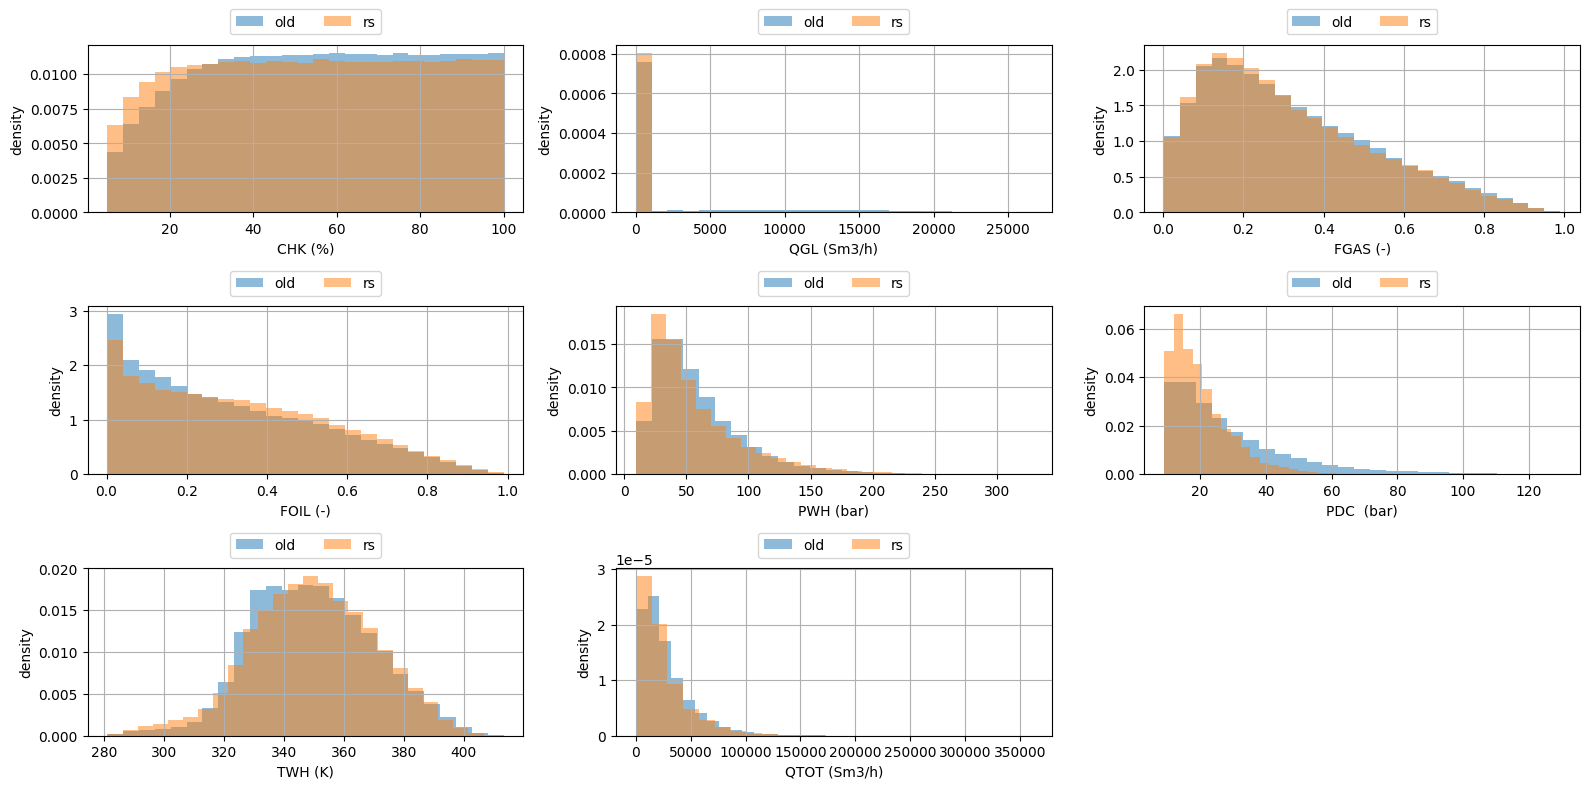

highest: if 1 sol, then include it. if 2 sol, take solution_number 1


<Figure size 640x480 with 0 Axes>

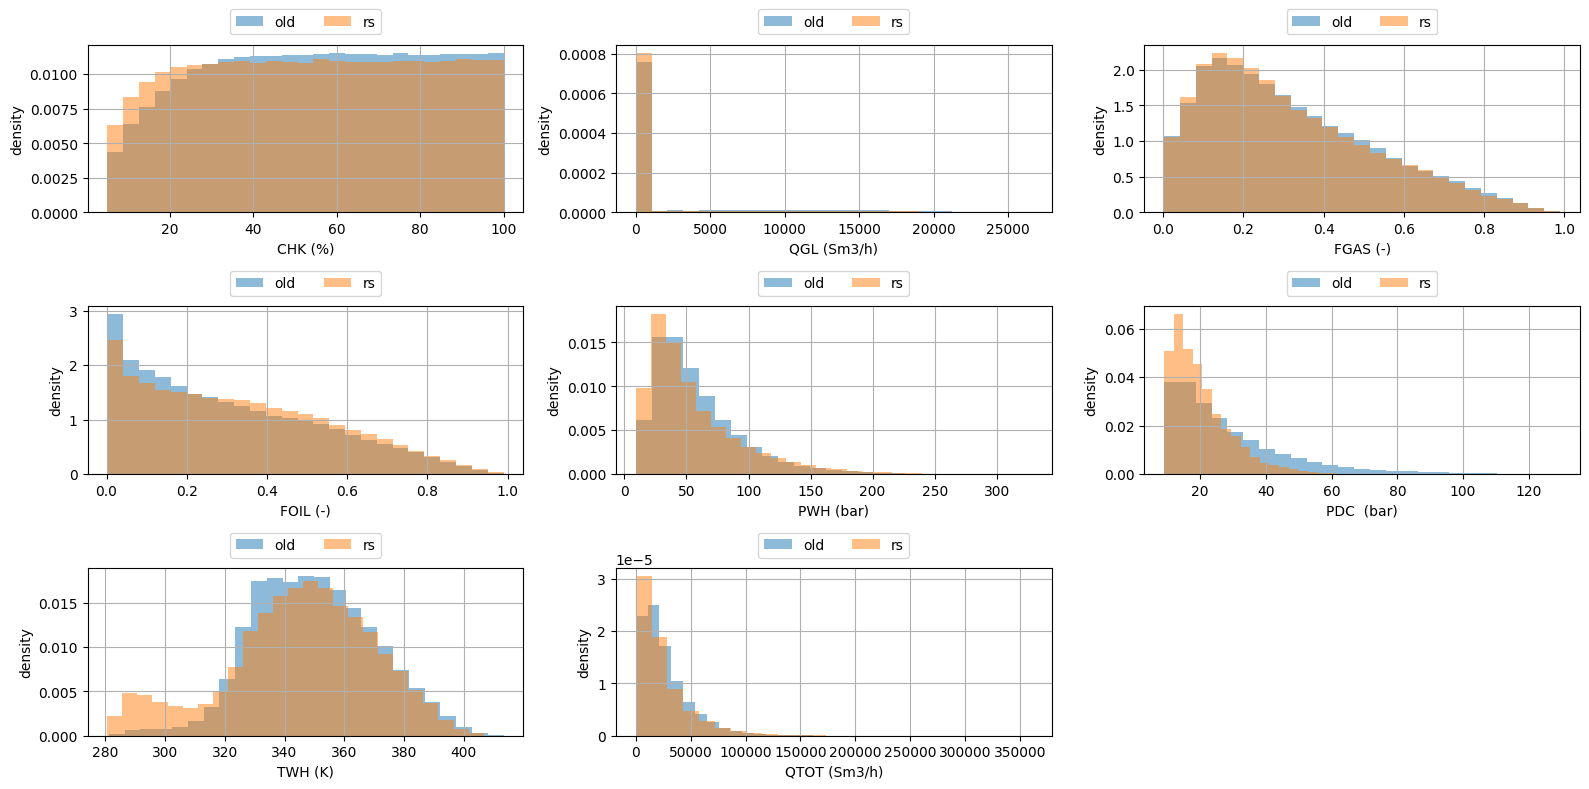

lowest, but excludes all cases were only one solution was found


<Figure size 640x480 with 0 Axes>

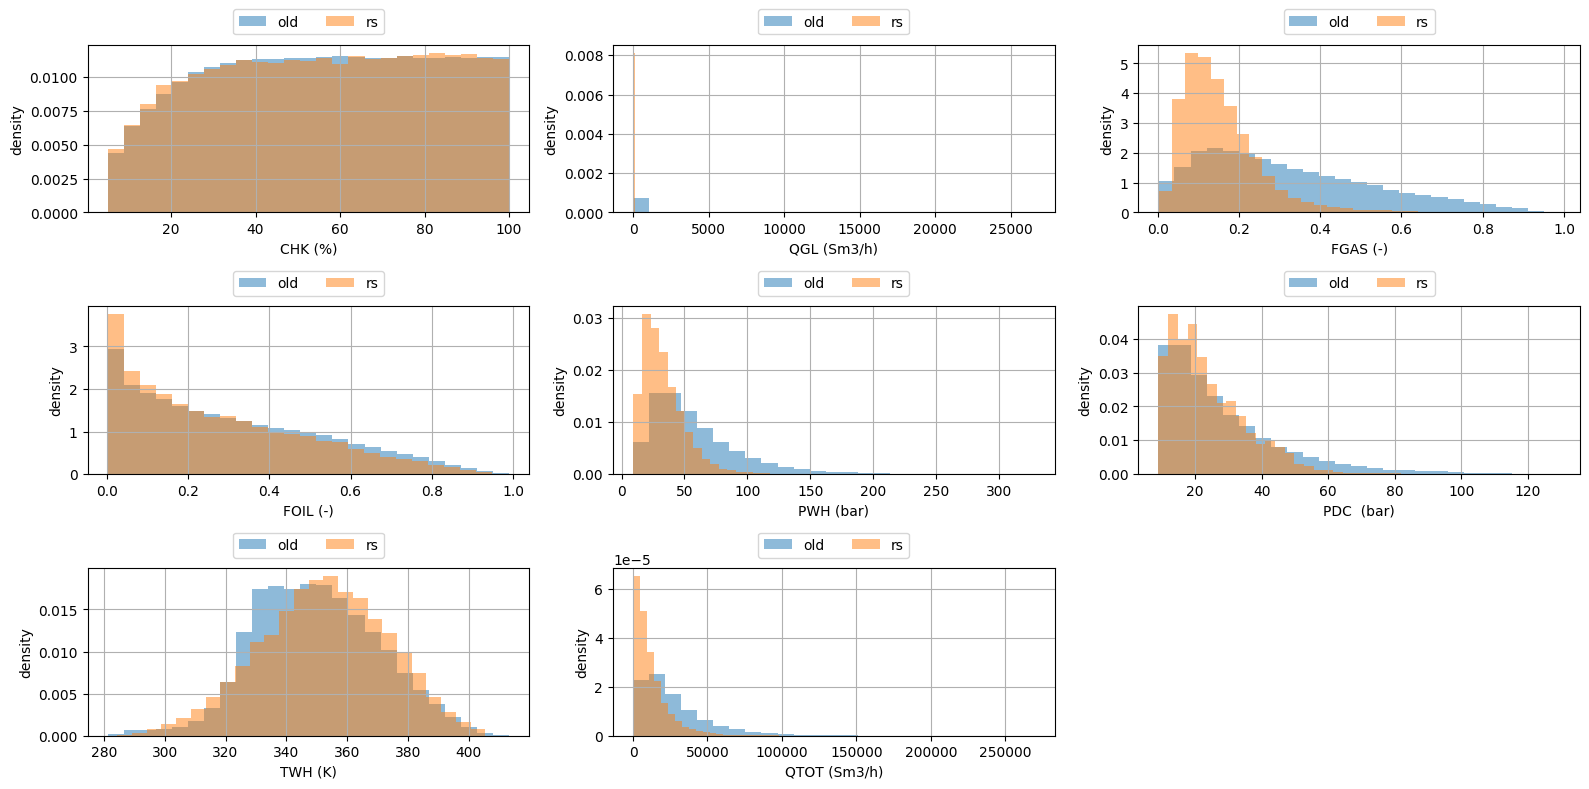

highest, but excludes all cases were only one solution was found


<Figure size 640x480 with 0 Axes>

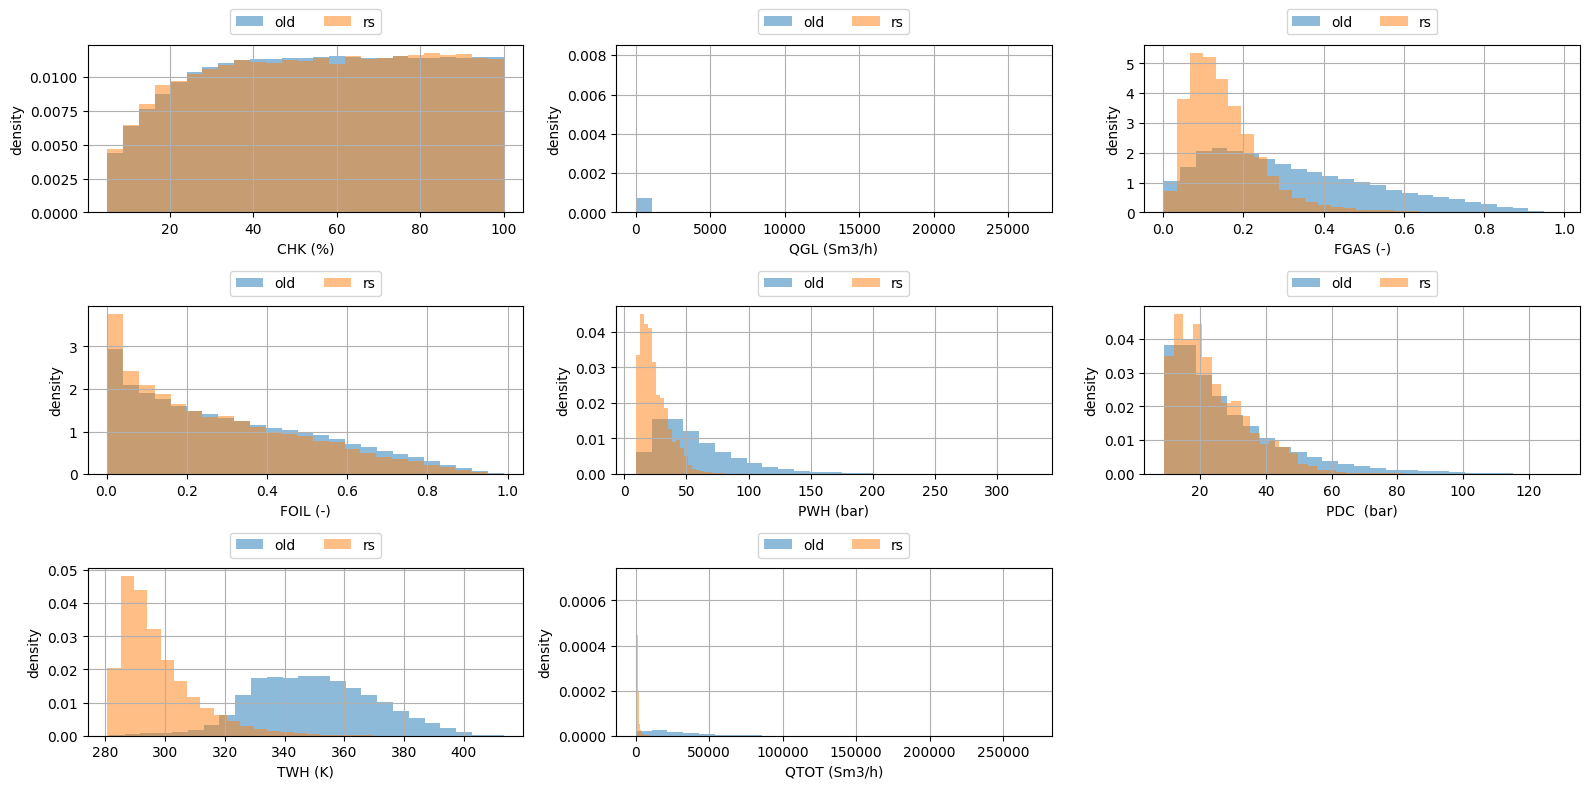

In [11]:
print("---------------- nsol -------------------")
print("lowest: if 1 sol, then include it. if 2 sol, take solution_number 0")
compare_distributions(df_nsol, df_nsol_rs_lowest, filename="manywells_nsol_compare_distributions_lowest_PBH")
print("highest: if 1 sol, then include it. if 2 sol, take solution_number 1")
compare_distributions(df_nsol, df_nsol_rs_highest, filename="manywells_nsol_compare_distributions_highest_PBH")
print("lowest, but excludes all cases were only one solution was found")
compare_distributions(df_nsol, df_nsol_rs_lowest_if_2, filename="manywells_nsol_compare_distributions_lowest_PBH_if_2_sols")
print("highest, but excludes all cases were only one solution was found")
compare_distributions(df_nsol, df_nsol_rs_highest_if_2, filename="manywells_nsol_compare_distributions_highest_PBH_if_2_sols")

# Convergence tests

Comparing the resulting values at the well head (z = L) for a random sample of well_ids over a range of discretization grids.

In [5]:
convergence_results = run_convergence(config_sol, well_ids=random.sample(range(0, 2000), 5), n_cells_list=[50, 100, 150])

Well 28: sweeping N in [50, 100, 150] ...

******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

Well 1467: sweeping N in [50, 100, 150] ...
Well 1599: sweeping N in [50, 100, 150] ...
Well 612: sweeping N in [50, 100, 150] ...
Well 1996: sweeping N in [50, 100, 150] ...


<Axes: title={'center': 'Convergence of v_g (Rust vs. old simulator)'}, xlabel='N (number of cells)', ylabel='|v_g_rust - v_g_old| at z = L'>

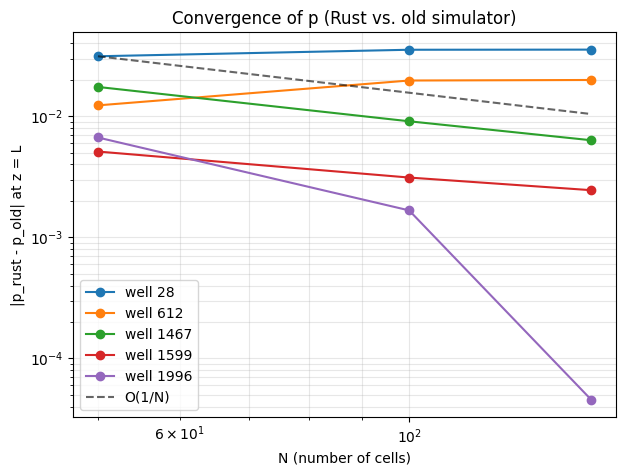

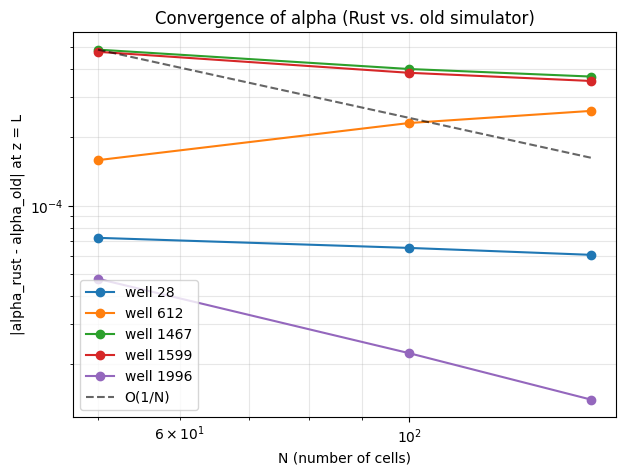

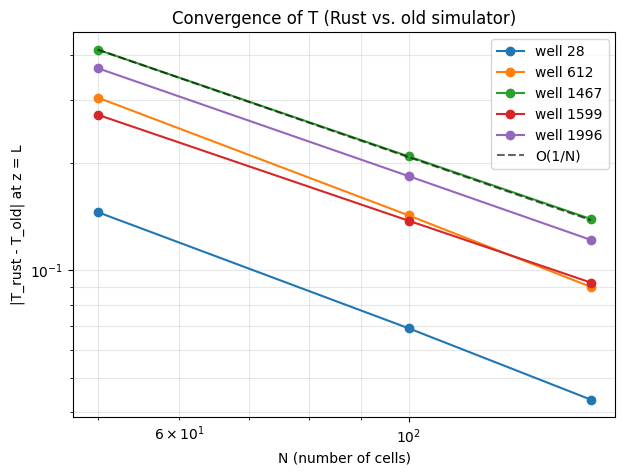

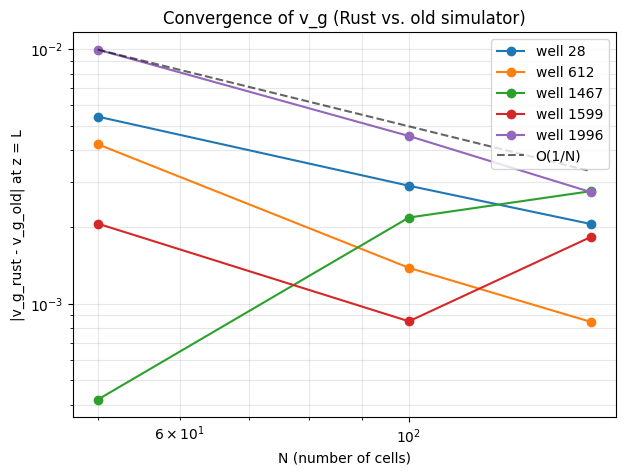

In [6]:
plot_convergence(convergence_results, variable='p')       # or 'alpha', 'T', etc.
plot_convergence(convergence_results, variable='alpha')       # or 'alpha', 'T', etc.
plot_convergence(convergence_results, variable='T')       # or 'alpha', 'T', etc.
plot_convergence(convergence_results, variable='v_g')       # or 'alpha', 'T', etc.

Use the `compare_operating_point` to compare the solution evolution over the entire well. In the cases where the rust simulator produces two solutions it plots both. The stars mark features found in the dataset.

Well 237, row 0, CHK=0.2257
             dataset   old (Ipopt) new (rust) #0 new (rust) #1
PBH       387.297827    381.758429    408.773303    381.758341
PWH       161.231092    157.288705     42.077617    157.330264
TBH       411.440636    411.440636    411.440636    411.440636
TWH       348.574472    347.797237    277.522173    348.024699
WGL              0.0           0.0           0.0           0.0
WGAS        4.596525      4.506349      0.018116      4.506364
WLIQ       11.733656     11.503462      0.046245     11.503499
WTOT        16.33018     16.009812      0.064361     16.009862
QGL              0.0           0.0           0.0           0.0
QGAS    21709.744869  21283.838824     85.562439  21283.905849
QLIQ       44.652776     43.776769      0.175986     43.776907
QTOT    21754.397645  21327.615593     85.738424  21327.682755
FGAS        0.281474      0.281474      0.281474      0.281474
CHOKED          True          True         False          True
FRBH      slug-churn    slu

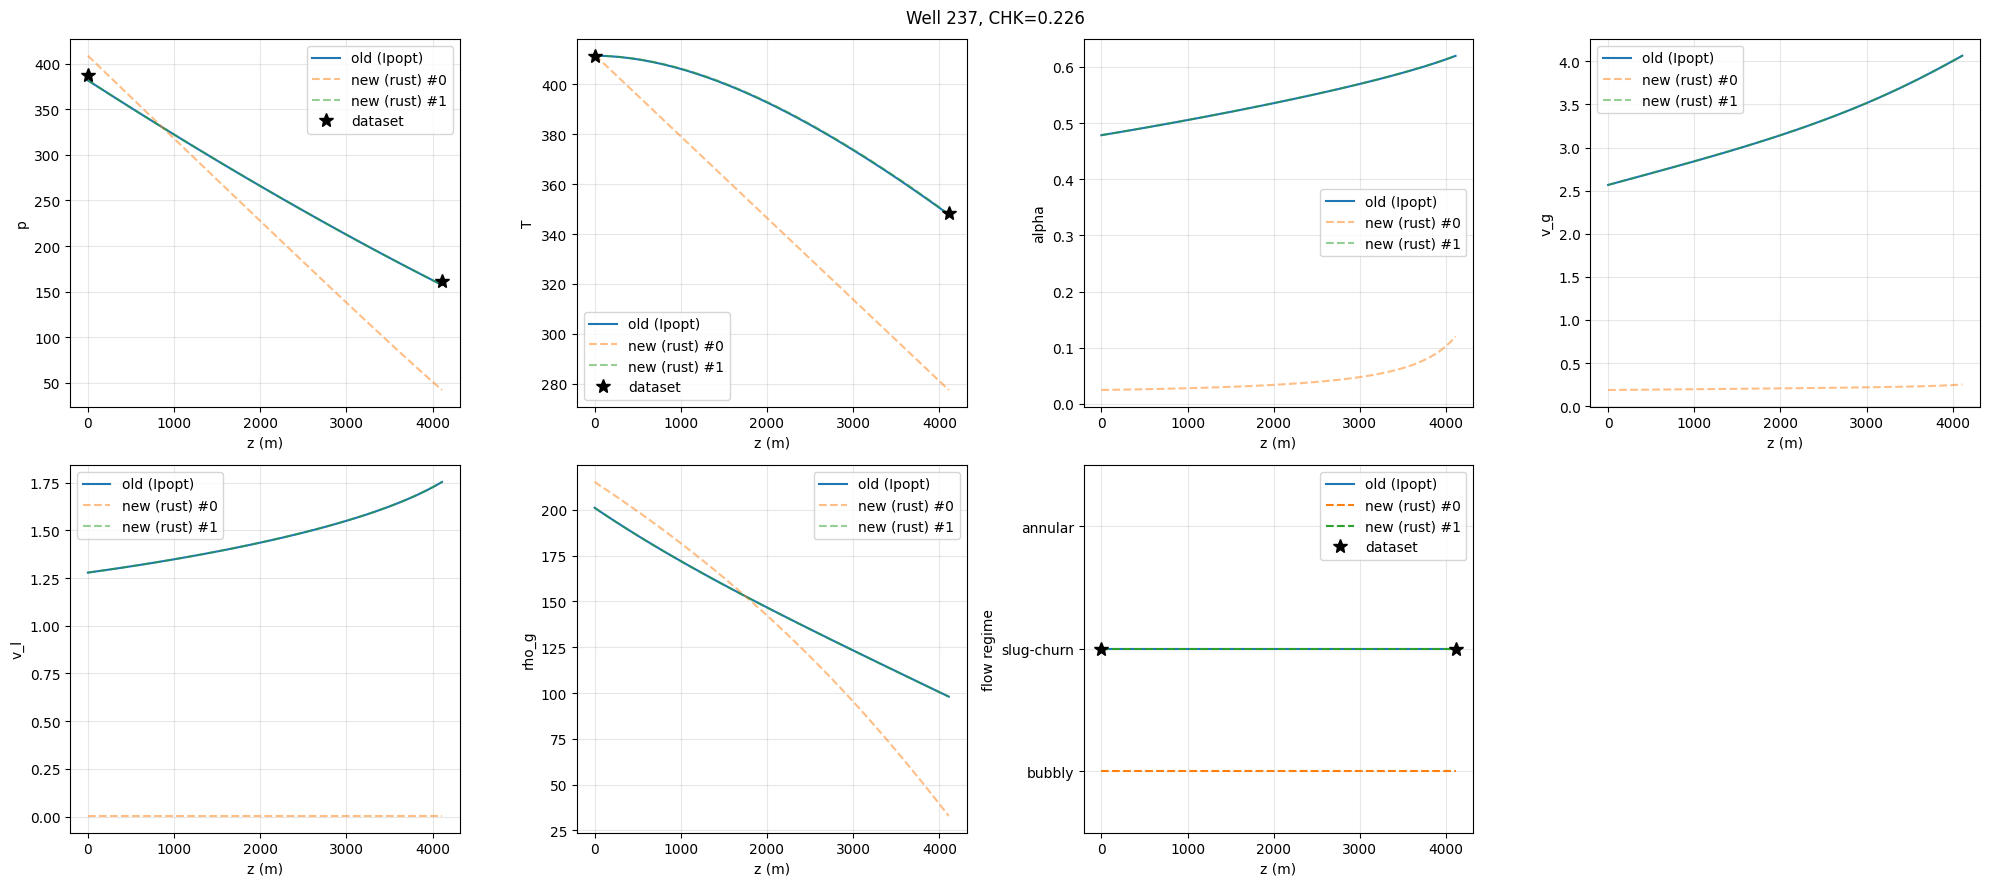

In [7]:
compare_operating_point(well_id=237, df_config=config_sol, df_data=df_sol)
print()

# Plot residual

The rust solver uses a shooting method on the initial bottomhole pressure $p(z=0)$. `plot_residual` plots the "error" in satisfying the choke model for each given $p(z=0) \in (p_\text{min}, p_\text{max})$.
The original simulator made an initial guess that 5% of the total pressure drop occurs at the inflow. This guess is marked in the plot.
When the simulator propagates a clamped solution ( to the top in an attempt to make the residual function smoother I mark this as "shady"
When the simulator fails I mark it as infeasible. 

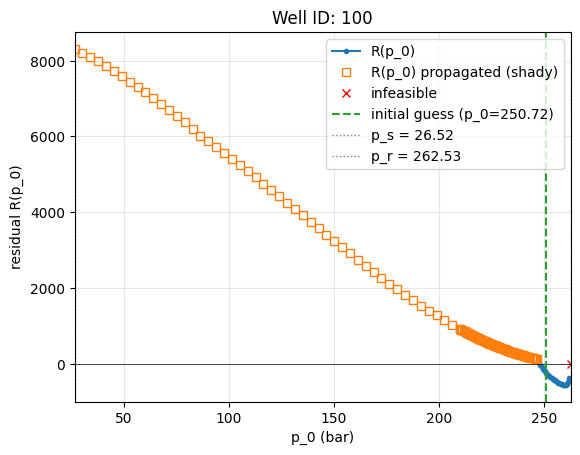

In [8]:
for WELL_ID in [100,]:
    wp, bc = load_well_config(WELL_ID, config_sol)
    s = sim_rs.SSDFSimulator(wp, bc)
    
    fig, ax = plt.subplots()
    p0s = np.concatenate([np.linspace(bc.p_s, 0.8 * bc.p_r, 50),
                              np.linspace(0.8 * bc.p_r, bc.p_r, 100)])
    p0s, residuals, _ = plot_residual(s, p_min=bc.p_s, p_max=bc.p_r, n_points=200, p0s=p0s, ax = ax)
    ax.set(title=f"Well ID: {WELL_ID}")
    plt.show()

# Benchmarking

The function `run_benchmark` can be used to measure solution times and accuracy. Running it without setting max_wells will run it on all wells (this takes time...)

In [9]:
# bench_results = run_benchmark(sim_names=["rust", "simulator"], max_wells=10)
bench_results = run_benchmark(sim_names=["rust", "simulator"], max_wells=100)

Simulator benchmark: rust, simulator
Data root: /home/oskar/manywells/data
Max wells per config: 100


CasADi - 2026-07-21 11:43:44 WARNING("S:nlp_jac_g failed: NaN detected for output jac_g_x, at nonzero index 4092 (row 703, col 700).") [.../casadi/core/oracle_function.cpp:377]
CasADi - 2026-07-21 11:43:44 WARNING("S:nlp_jac_g failed: NaN detected for output jac_g_x, at nonzero index 4092 (row 703, col 700).") [.../casadi/core/oracle_function.cpp:377]
CasADi - 2026-07-21 11:43:54 WARNING("S:nlp_jac_g failed: NaN detected for output jac_g_x, at nonzero index 4092 (row 703, col 700).") [.../casadi/core/oracle_function.cpp:377]
CasADi - 2026-07-21 11:44:11 WARNING("KeyboardInterruptException") [.../casadi/interfaces/ipopt/ipopt_nlp.cpp:132]

KeyboardInterrupt



KeyboardInterrupt: 

In [ ]:
bench_results[2]['rust']['failed_ids']

# Formulating and solving minimization problems

We can use the new rust solver as a "black box" function. Consider the following:

Let
$$
    F(w_m, w_{lg}) = (w_m - w_{ref})^2 + c w_{lg}^2,
$$
for some reference total flow $w_{ref}$ and scaling factor $c$.
Let $G(x; w_{lg})$ be the discretized DAE that the rust simulator solves, with $w_{lg}$ as a parameter
and $x$ as the solution vector containing `[p, v_g, v_l, alpha, rho_g, rho_l, T]` for all the cells.
The problem is:
\begin{align}
    \min &F(w_m, w_{lg}) \\
    \text{s.t. } &G(x, w_{lg}) = 0
\end{align}
The total flux $w_m = w_l + w_g$ is given by the solution to $G(x, w_{lg}) = 0$. So, the optimization problem
reduces to a 1D one:
$$
    \min_{w_{lg}} F(w_m(w_{lg}), w_{lg})
$$
The paper adds the control variable $s$ that parametrizes the choke $u_c$ and the gas lift $w_{lg}$ as
\begin{align}
    u_c &= \text{min}(1, s) \\
    w_{lg} &= \text{max}(0, s - 1)
\end{align}
Thus, the 1D minimization problem is a problem in $s$ instead.
It can be solved with `scipy.optimize.minimize_scalar`.


See `scripts/opt_with_rust_simulator.py`.


In [34]:
!uv run python scripts/compare_opt_rust_vs_cl.py --max-wells 50

Config: /home/oskar/manywells/data/manywells-nscl/manywells-nscl-1_config.zip
Comparing 50 wells  (w_ref=median WTOT)
------------------------------------------------------------------------------------------
well    0  w_ref= 26.220  [ok]  u: 1.0000 vs 1.0000  w_lg: 2.2341 vs 2.2365  du=+0.0000  dw_lg=+0.0024  dt=+2.93s  speedup=7.7x
well    1  w_ref= 16.150  [ok]  u: 1.0000 vs 1.0000  w_lg: 0.0000 vs 0.0000  du=-0.0000  dw_lg=-0.0000  dt=+3.01s  speedup=5.4x
well    2  w_ref=  5.826  [ok]  u: 0.5020 vs 1.0000  w_lg: 0.0000 vs 0.0000  du=+0.4980  dw_lg=+0.0000  dt=+5.00s  speedup=6.1x
CasADi - 2026-07-21 15:13:41 WARNING("nlpsol:nlp_grad_f failed: NaN detected for output grad_f_x, at (row 1638, col 0).") [.../casadi/core/oracle_function.cpp:377]
CasADi - 2026-07-21 15:13:41 WARNING("nlpsol:nlp_jac_g failed: NaN detected for output jac_g_x, at nonzero index 9586 (row 1641, col 1638).") [.../casadi/core/oracle_function.cpp:377]
well    3  w_ref= 10.246  [ok]  u: 1.0000 vs 1.0000  w_lg: 

# Just playing around

The rest of this notebook is just me playing around with the simulators